In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 


In [7]:
df = pd.read_csv('street_performer_tips.csv')
print(df.isnull().sum())
print(df.info())

Performance Hours    4
Crowd Size (avg)     0
tricks_per_hour      0
weekend              0
weather_score        3
costume_quality      0
interaction_level    0
location_type        2
daily_tips           3
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Performance Hours  252 non-null    float64
 1   Crowd Size (avg)   256 non-null    int64  
 2   tricks_per_hour    256 non-null    int64  
 3   weekend            256 non-null    int64  
 4   weather_score      253 non-null    float64
 5   costume_quality    256 non-null    int64  
 6   interaction_level  256 non-null    int64  
 7   location_type      254 non-null    str    
 8   daily_tips         253 non-null    float64
dtypes: float64(3), int64(5), str(1)
memory usage: 18.1 KB
None


Lets Start with Column names fixing


In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_').str.replace(')','').str.replace('(','')
print(df.columns)

Index(['performance_hours', 'crowd_size_avg', 'tricks_per_hour', 'weekend',
       'weather_score', 'costume_quality', 'interaction_level',
       'location_type', 'daily_tips'],
      dtype='str')


Column names are fixes now Contents in those columns can be problem

In [9]:
print(df.isnull().sum())
print(f"Shape of data is {df.shape}")

performance_hours    4
crowd_size_avg       0
tricks_per_hour      0
weekend              0
weather_score        3
costume_quality      0
interaction_level    0
location_type        2
daily_tips           3
dtype: int64
Shape of data is (256, 9)


3 missing data in Daily tips. We can do two things, we take estimate or give up those records, its only 3 so we can drop them altogether 
1. We also need to check the value_counts of str type because that can be problematic most of times in real world data for str type column it can contain whitespaces and wrong format inputs.
2. We set usual Cases with strip and lower and replace, We can also do Capitalize as well but lets go with lower

In [ ]:
df['location_type']= df['location_type'].str.strip().str.replace(' ','_').str.lower()
print(df["location_type"].value_counts(dropna=False))

location_type
subway          71
market          64
tourist_spot    63
park            56
NaN              2
Name: count, dtype: int64


In [14]:
print(df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(by=['daily_tips'])

6


,performance_hours,crowd_size_avg,tricks_per_hour,weekend,weather_score,costume_quality,interaction_level,location_type,daily_tips
5,7.0,29,7,0,10.0,5,3,park,173.30
243,7.0,29,7,0,10.0,5,3,park,173.30
187,4.0,25,7,1,5.0,5,8,market,190.58
23,4.0,25,7,1,5.0,5,8,market,190.58
245,5.0,30,12,0,8.0,4,7,market,198.28
83,5.0,30,12,0,8.0,4,7,market,198.28
166,3.0,44,10,1,3.0,10,7,subway,217.86
230,3.0,44,10,1,3.0,10,7,subway,217.86
46,7.0,35,17,0,2.0,9,4,tourist_spot,224.13
49,7.0,35,17,0,2.0,9,4,tourist_spot,224.13


In [17]:
df = df.dropna(subset=["daily_tips"]).copy()
df = df.dropna(subset=["location_type"]).copy()
df = df.drop_duplicates().reset_index(drop=True)

In [19]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   performance_hours  241 non-null    float64
 1   crowd_size_avg     245 non-null    int64  
 2   tricks_per_hour    245 non-null    int64  
 3   weekend            245 non-null    int64  
 4   weather_score      242 non-null    float64
 5   costume_quality    245 non-null    int64  
 6   interaction_level  245 non-null    int64  
 7   location_type      245 non-null    str    
 8   daily_tips         245 non-null    float64
dtypes: float64(3), int64(5), str(1)
memory usage: 17.4 KB
None
performance_hours    4
crowd_size_avg       0
tricks_per_hour      0
weekend              0
weather_score        3
costume_quality      0
interaction_level    0
location_type        0
daily_tips           0
dtype: int64


In [20]:
df['performance_hours'] = df['performance_hours'].fillna(df['performance_hours'].median())

df['weather_score'] = df['weather_score'].fillna(df.groupby('location_type')['weather_score'].transform('median'))

print(df.isnull().sum())

performance_hours    0
crowd_size_avg       0
tricks_per_hour      0
weekend              0
weather_score        0
costume_quality      0
interaction_level    0
location_type        0
daily_tips           0
dtype: int64


We got No nulls now, This step is for outlier detection or anomalies in the Data which can do injustice to our Model Training

In [21]:
df.describe()

,performance_hours,crowd_size_avg,tricks_per_hour,weekend,weather_score,costume_quality,interaction_level,daily_tips
count,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000
mean,4.428571,39.865306,9.922449,0.355102,5.942857,6.448980,5.906122,191.934408
std,2.293969,22.411626,4.535618,0.487996,2.649776,2.322919,2.654134,60.282918
min,1.000000,8.000000,3.000000,0.000000,0.000000,3.000000,-3.000000,-15.000000
25%,3.000000,27.000000,6.000000,0.000000,4.000000,5.000000,4.000000,163.190000
50%,4.000000,37.000000,10.000000,0.000000,6.000000,6.000000,6.000000,191.270000
75%,6.000000,47.000000,14.000000,1.000000,8.000000,8.000000,8.000000,219.320000
max,14.000000,250.000000,17.000000,2.000000,10.000000,15.000000,10.000000,850.000000


Performace_hours Maxes at 14 which can be True.
Daily tips max at 850 which is far above normal but thats in subway maybe some rich kid gave big tip
Daily tips minimum is -15 which is not possible maybe - was added by mistake 
Crowd of 250 in a subway is normal in peaktimes.
costume quality 15 is wrong or just swept away by emotions , Need to scale it down or drop 
interaction level goes to -3 which is not possible .
weekend can be or cannot be so no 2 it should be 1 and typo error 



In [22]:
df['weekend']= df['weekend'].replace(2,1) #removes our typo in csv
df = df[df['daily_tips']>=0] #daily tips can be positive never negatives
df = df[df['interaction_level']>=0] #interaction level can only be positive 
df['costume_quality'] = df['costume_quality'].clip(upper=10)  #maybe csv number 15 was out of emotions and circumstances 

df = df.reset_index(drop=True)

print(df.shape)
print(df.describe())

(243, 9)
       performance_hours  crowd_size_avg  tricks_per_hour     weekend  \
count         243.000000      243.000000       243.000000  243.000000   
mean            4.427984       39.732510         9.893004    0.353909   
std             2.302971       22.331057         4.540551    0.479168   
min             1.000000        8.000000         3.000000    0.000000   
25%             2.500000       27.000000         6.000000    0.000000   
50%             4.000000       37.000000        10.000000    0.000000   
75%             6.000000       47.000000        14.000000    1.000000   
max            14.000000      250.000000        17.000000    1.000000   

       weather_score  costume_quality  interaction_level  daily_tips  
count     243.000000       243.000000         243.000000  243.000000  
mean        5.934156         6.419753           5.942387  192.559918  
std         2.644928         2.264700           2.602600   58.942770  
min         0.000000         3.000000           2

how lets visualize data 

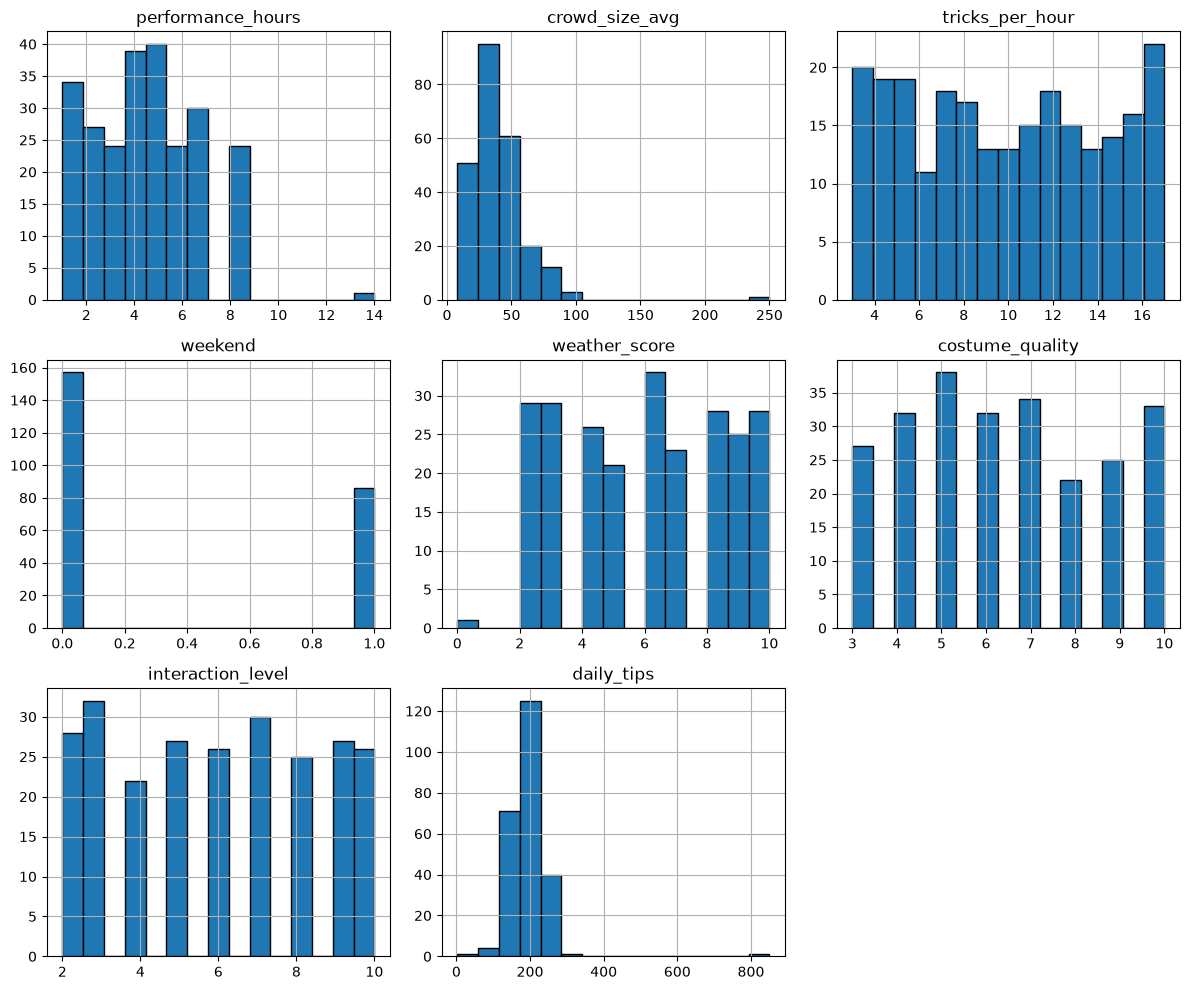

In [24]:
df.hist(bins=15, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
plt.show()

daily_tips           1.000000
performance_hours    0.386242
weekend              0.320867
interaction_level    0.250336
crowd_size_avg       0.237084
weather_score        0.160230
costume_quality      0.131922
tricks_per_hour      0.068272
Name: daily_tips, dtype: float64


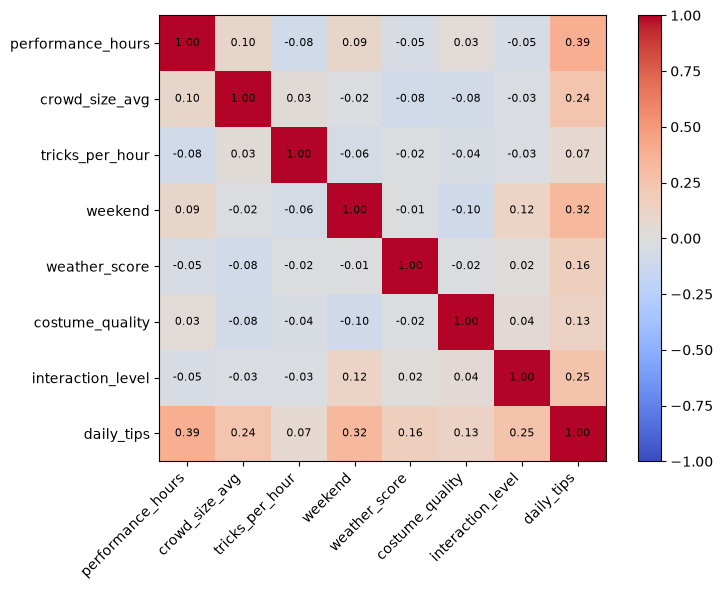

In [25]:
# ... existing code ...

corr = df.corr(numeric_only=True)

# which features actually track the target?
print(corr['daily_tips'].sort_values(ascending=False))

# heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im)
plt.tight_layout()
plt.show()

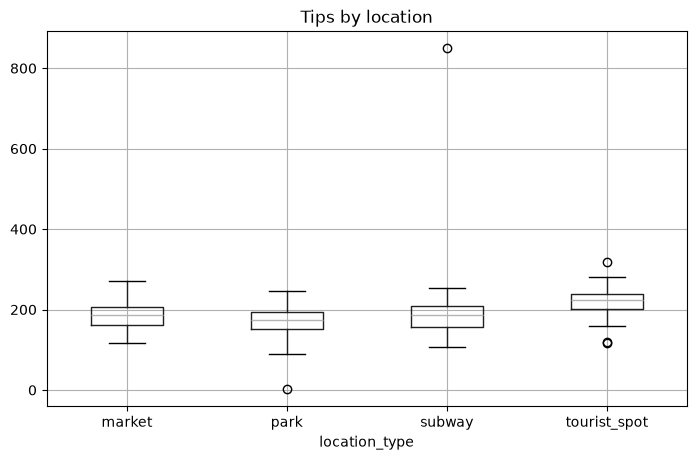

In [26]:
# ... existing code ...

df.boxplot(column='daily_tips', by='location_type', figsize=(8, 5))
plt.suptitle('')
plt.title('Tips by location')
plt.show()

In [ ]:
# ... Step 8 code above ...

# --- Step 9: Encode location_type ---

# sanity check: must be exactly 4 clean categories (park, subway, market, tourist_spot)
print(df['location_type'].value_counts())

df = pd.get_dummies(df, columns=['location_type'], drop_first=True, dtype=int)

print(df.columns)
print(df.shape)   # 4 columns wider... no wait, 3 wider (4 categories - 1 dropped)
print()

location_type
subway          68
market          61
tourist_spot    60
park            54
Name: count, dtype: int64
Index(['performance_hours', 'crowd_size_avg', 'tricks_per_hour', 'weekend',
       'weather_score', 'costume_quality', 'interaction_level', 'daily_tips',
       'location_type_park', 'location_type_subway',
       'location_type_tourist_spot'],
      dtype='str')
(243, 11)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

